# Electrograms from local activation times

This tutorial approximates electrograms (EGMs) from a local activation time (LAT) map, one action-potential (AP) template, and a spatial sensitivity field for each electrode. A Fenton–Karma simulation supplies the LAT map, the AP template, and reference electrograms for comparison.

Two methods use the same assumption that every tissue point follows a common AP waveform shifted to its local activation time:

- **Method 1: gradient weights and convolution.** Combine spatial LAT and lead-field gradients, accumulate the resulting weights into activation-time bins, and convolve with the AP derivative. This avoids constructing a voltage trace at every tissue point.
- **Method 2: reconstructed voltages and a discrete operator.** Reconstruct the voltage at every node and time, then project it onto electrode weights precomputed from the simulation's spatial operator.

The use of activation-shifted AP templates follows the modeling approach discussed by [Pezzuto et al. (2017)](https://doi.org/10.3389/fphys.2017.00265). The electrode sensitivity formulation is motivated by the lead-field treatment in [Potse (2018)](https://doi.org/10.3389/fphys.2018.00370). The notebook illustrates simplified implementations rather than a complete bidomain or torso model.

## 1. Define the electrode fields

In a homogeneous volume conductor, the sensitivity of a point electrode decreases with its distance from the tissue. The scaled electrode field is

$$
L_{m,p}=\frac{1}{4\pi D_{\mathrm{volume}}}
\frac{1}{r_{m,p}},
\qquad
r_{m,p}=dr\,\|\mathbf{i}_p-\mathbf{i}_m\|.
$$

The quantities in these equations are:

- $L_{m,p}$: the scaled sensitivity of electrode $m$ to tissue node $p$.
- $m$ and $p$: the electrode and tissue-node indices, respectively.
- $dr$: the uniform grid spacing in millimeters.
- $D_{\mathrm{volume}}$: the conductivity parameter of the homogeneous volume conductor surrounding the tissue.
- $\mathbf{i}_p$: the position of tissue node $p$ in grid units.
- $\mathbf{i}_m$: the position of electrode $m$ in grid units, including its height above the tissue sheet.
- $r_{m,p}$: the physical distance between electrode $m$ and node $p$, in millimeters.
- $\|\cdot\|$: the Euclidean norm.
- $\pi$: the mathematical constant pi.

The tissue sheet lies at zero height, and the electrodes lie above it so that $r_{m,p}>0$. The field includes the cell-volume and conductivity scaling factors. EGM amplitudes are expressed in arbitrary units because the action-potential template is normalized.


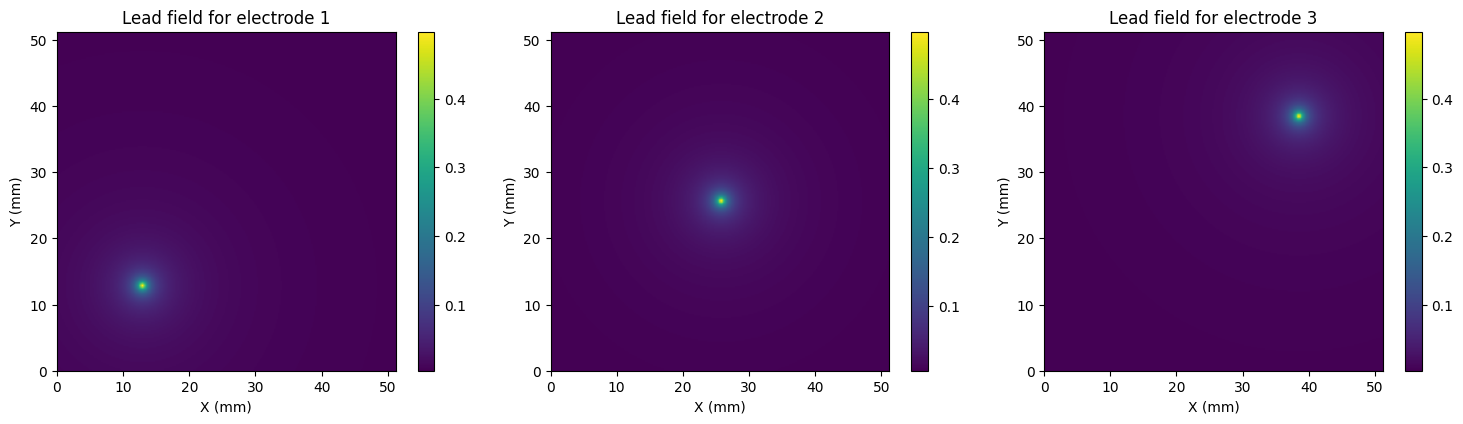

In [1]:
import numpy as np
import matplotlib.pyplot as plt


def compute_lead_field(lead_coords, shape, dr, volume_cond=0.4):
    """Compute the lead field as an inverse distance function on a 2D or 3D grid.
    """
    lead_coords = np.atleast_2d(lead_coords)

    if len(shape) == 2:
        shape = (shape[0], shape[1], 1)

    x, y, z = np.indices(shape)
    coords = np.stack((x.ravel(), y.ravel(), z.ravel()), axis=-1)

    distance = dr * np.linalg.norm(coords[None, :, :] - 
                                   lead_coords[:, None, :], axis=-1)

    coeff = 1 / (4 * np.pi * volume_cond)
    lead_field = coeff / distance
    
    return lead_field


grid_size = 256
dr = 0.2
D_model = 0.1
D_intra = 0.2
D_volume = 0.4

height_offset = 2
lead_coords = np.array([
    (0.25 * grid_size, 0.25 * grid_size, height_offset),
    (0.50 * grid_size, 0.50 * grid_size, height_offset),
    (0.75 * grid_size, 0.75 * grid_size, height_offset)
    ])

lead_fields = compute_lead_field(lead_coords, shape=(grid_size, grid_size), 
                                 volume_cond=D_volume, dr=dr)

fig, axs = plt.subplots(1, len(lead_coords), figsize=(15, 4))
for i, ax in enumerate(axs):
    im = ax.imshow(lead_fields[i].reshape(grid_size, grid_size),
                   cmap="viridis", origin="lower",
                   extent=[0, grid_size * dr, 0, grid_size * dr])
    ax.set_title(f"Lead field for electrode {i + 1}")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()


## 2. Generate a LAT map and an AP template

The example uses a `256 × 256` grid with `dr = 0.2` mm, the Fenton–Karma model, and a central circular region with conductivity reduced to `0.3` instead of `1.0`. A corner stimulus initiates propagation. `ActivationTimeTracker` records the first sampled crossing above 0.5, while `ActionPotentialTracker` records the AP at `[10, 10]`. `LeadFieldECGTracker` uses the same electrode fields to record reference signals from the simulated voltage distribution.

The integration step is `0.01 ms` and both trackers run every `10` steps, giving a nominal sample interval of `0.1 ms`. The AP derivative and the EGM time bins must use the AP sampling interval, not the integration step. This example assumes every included cell has activated and that the LAT map is finite and spatially meaningful.

Running FentonKarma on (256, 256) Grid:   0%|          | 0/15000 [00:00<?, ?it/s]

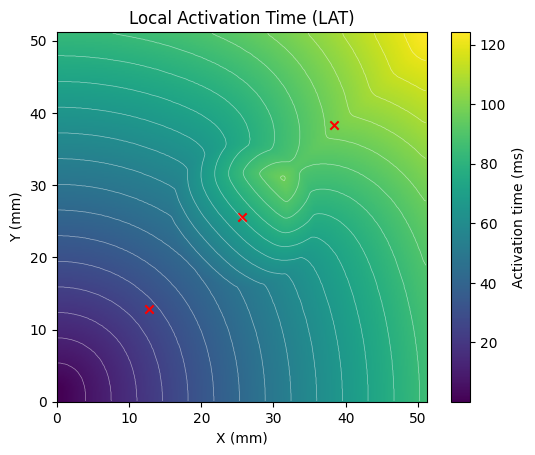

In [2]:
import numpy as np
from scipy import ndimage
import matplotlib.pyplot as plt
import finitewave as fw


dist_map = np.zeros((grid_size, grid_size))
dist_map[grid_size // 2, grid_size // 2] = 1.0
dist_map = ndimage.distance_transform_edt(1 - dist_map)
mask = dist_map < 50

tissue = fw.CardiacTissue(shape=(grid_size, grid_size), dr=dr)
tissue.conductivity = np.ones((grid_size, grid_size))
tissue.conductivity[mask] = 0.3

cardiac_model = fw.FentonKarma()
cardiac_model.D_model = D_model

stim_sequence = fw.StimSequence()
stim_sequence.add_stim(fw.StimVoltageCoord(time=0, volt_value=1.0,
                                           x_min=0, x_max=10,
                                           y_min=0, y_max=2))

act_pot_tracker = fw.ActionPotentialTracker([10, 10], step=10)
lat_tracker = fw.ActivationTimeTracker(threshold=0.5, step=10)
ecg_tracker = fw.LeadFieldECGTracker(lead_fields=lead_fields, step=10,
                                     mono_to_intra_ratio=D_intra / D_model)

tracker_sequence = fw.TrackerSequence()
tracker_sequence.add_tracker(lat_tracker)
tracker_sequence.add_tracker(act_pot_tracker)
tracker_sequence.add_tracker(ecg_tracker)

simulation = fw.CardiacSimulation(dt=0.01, t_max=150, backend="jax")
simulation.cardiac_tissue = tissue
simulation.cardiac_model = cardiac_model
simulation.stim_sequence = stim_sequence
simulation.tracker_sequence = tracker_sequence

simulation.run()

lats = lat_tracker.output

plt.figure()
img = plt.imshow(lats, cmap="viridis", origin="lower",
                 extent=[0, grid_size * dr, 0, grid_size * dr])
plt.scatter(lead_coords[:, 0] * dr, lead_coords[:, 1] * dr, c="red", marker="x", label="Leads")
plt.colorbar(img, label="Activation time (ms)")
plt.contour(lats, origin="lower", levels=20, colors="white", linewidths=0.5, alpha=0.5,
            extent=[0, grid_size * dr, 0, grid_size * dr])
plt.title("Local Activation Time (LAT)")
plt.xlabel("X (mm)")
plt.ylabel("Y (mm)")
plt.show()

## 3. Method 1: gradient weights and convolution

The electrogram at electrode $e$ can be expressed as a spatial integral over the tissue:

$$
\mathrm{EGM}_e(t)=\int_{\Omega}
\nabla L_e(\mathbf{x})\cdot
\left[D_{\mathrm{intra}}(\mathbf{x})\nabla V_m(\mathbf{x},t)\right]
\,d\Omega.
$$

Here $\Omega$ is the tissue domain, $L_e$ is the electrode's lead field, $D_{\mathrm{intra}}$ is the intracellular conductivity coefficient (or tensor for anisotropic tissue), and $V_m$ is the transmembrane potential. $d\Omega$ is the tissue volume element.

To calculate this integral from LATs, we assume that every node follows the same AP waveform shifted to its activation time. This separates the voltage gradient into a temporal AP derivative and a spatial LAT gradient, making it possible to calculate the signal by convolution.

### 3.1. Prepare the AP template

Let $V_0(s)$ be the template action potential and $a$ its activation time. Assuming the same AP shape at every tissue point, the local activation time $\tau(\mathbf{x})$ determines its temporal shift:

$$
V_m(\mathbf{x},t)=V_0\bigl(t-\tau(\mathbf{x})+a\bigr).
$$

Here $a$ is the activation time within the recorded AP template, taken by default at the maximum upstroke slope; it aligns the template activation with the local LAT.

Define the AP derivative relative to activation as

$$
g(u)=V_0'(u+a).
$$

Applying the chain rule gives

$$
\nabla V_m(\mathbf{x},t)
=-V_0'\bigl(t-\tau(\mathbf{x})+a\bigr)\nabla\tau(\mathbf{x})
=-g\bigl(t-\tau(\mathbf{x})\bigr)\nabla\tau(\mathbf{x}).
$$

This separates the temporal AP waveform from the spatial activation pattern, allowing the EGM calculation to combine one AP derivative with the LAT map. The example retains the first 6 ms of the template to focus on depolarization; the template activation time and the LAT map should use the same activation criterion for consistent alignment. Here the template uses the maximum upstroke slope, whereas the LAT tracker uses a 0.5 threshold, so a timing offset can remain.

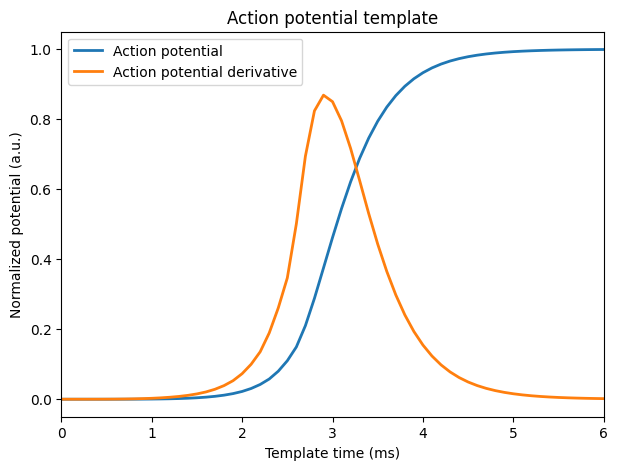

In [3]:
def compute_ap_derivative(v_ap, dt=0.1, act_time=None, upstroke_window=None):
    """Compute the time derivative of an action potential (AP) template.

    Parameters
    ----------
    v_ap : array_like
        Action potential template, sampled at uniform time intervals.
    dt : float, optional
        Time step between samples in v_ap (default: 0.1 ms).
    act_time : float, optional
        Activation time on the template clock (ms); defaults to maximum upstroke slope.
    upstroke_window : tuple of float, optional
        Absolute template-time window (start, end) in ms to restrict the derivative calculation
        to the upstroke phase of the AP (default: None, which uses the entire AP).

    Returns
    -------
    dvdt : ndarray
        Time derivative of the action potential, restricted to the upstroke window if specified.
    act_time : float
        Activation time on the template clock (ms).
    end_time : float
        Retained sample count times dt (ms), not the last absolute sample time.
    """
    v_ap = np.asarray(v_ap, dtype=float)
    dvdt = np.gradient(v_ap, dt)
    ap_times = np.arange(len(v_ap)) * dt

    if act_time is None:
        act_time = np.argmax(dvdt) * dt

    if upstroke_window is not None:
        start, end = upstroke_window

        if start < 0 or end > ap_times[-1]:
            raise ValueError("Upstroke window is out of bounds of the action potential template.")
        
        if start > act_time or end < act_time:
            raise ValueError("Upstroke window does not include the activation time.")

        keep = (ap_times >= start) & (ap_times <= end)

        if not np.any(keep):
            raise ValueError("Upstroke window does not overlap the template.")
        
        dvdt = dvdt[keep]

    end_time = len(dvdt) * dt
    
    return dvdt, act_time, end_time


ap_times = act_pot_tracker.tracking_times
ap_voltage = act_pot_tracker.output
upstroke_window = [0, 6]  # ms
dvdt, ap_act_time, ap_end_time = compute_ap_derivative(ap_voltage, dt=0.1, upstroke_window=[0, 6])

dvdt_times = upstroke_window[0] + np.arange(len(dvdt)) * 0.1

plt.figure(figsize=(7, 5))
plt.plot(ap_times, ap_voltage, lw=2, label="Action potential")
plt.plot(dvdt_times, dvdt, lw=2, label="Action potential derivative")
plt.title("Action potential template")
plt.ylabel("Normalized potential (a.u.)")
plt.xlabel("Template time (ms)")
plt.xlim(0, 6)
plt.legend()
plt.show()

### 3.2. Form the spatial source weights

Using the signal polarity chosen for this calculation, we write

$$
\mathrm{EGM}_e(t)=\int_{\Omega}
\left[\nabla L_e(\mathbf{x})\cdot D_{\mathrm{intra}}(\mathbf{x})\nabla\tau(\mathbf{x})\right]
g\bigl(t-\tau(\mathbf{x})\bigr)\,d\Omega.
$$

At this stage, we precompute only the time-independent spatial factor

$$
w_e(\mathbf{x})=\nabla L_e(\mathbf{x})\cdot
D_{\mathrm{intra}}(\mathbf{x})\nabla\tau(\mathbf{x}).
$$

It combines the electrode sensitivity gradient, intracellular conductivity, and the spatial activation-time gradient. For each electrode $e$ and tissue node $p$, the code evaluates

$$
w_{e,p}=dr^3 d_{\mathrm{intra},p}
\sum_{k=0}^{1}(\partial_k L_e)_p(\partial_k\tau)_p,
\qquad
d_{\mathrm{intra},p}=D_{\mathrm{intra}}\,C_p,
$$

where $C_p$ is the local tissue conductivity multiplier and $k$ runs over the two spatial axes. These values are stored in `source_weights` and plotted below. The cell-volume factor is also applied at this stage.

In the next section, we will convolve the weighted activation-time distribution with the AP derivative and integrate over the tissue to obtain the electrograms.

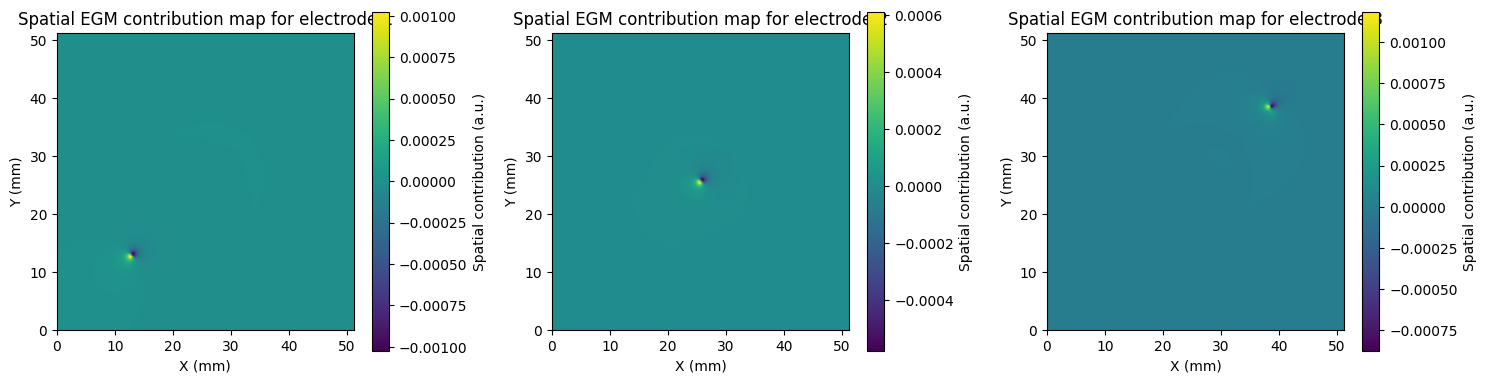

In [4]:
def compute_gradients(grad_ops, x):
    """Compute spatial gradients using a gradient operator.

    Parameters
    ----------
    grad_ops : sequence of sparse matrices
        One (P, P) derivative operator per spatial axis.
    x : ndarray
        One scalar field containing P values in the operators' node ordering.

    Returns
    -------
    grad : ndarray
        Spatial derivatives shaped (ndim, P), ordered by mesh axis.
        No area factor is applied.
    """
    x = np.asarray(x, dtype=float)
    x = x.ravel()

    grads = np.stack([g @ x for g in grad_ops], axis=0)

    return grads

spatial_discretization = fw.FiniteDifferenceGradient()
grad_ops = spatial_discretization.build_gradient_operator(tissue.mesh, dr=dr)

lead_field_grads = np.array([compute_gradients(grad_ops, lead_field) for lead_field in lead_fields])
lat_grad = compute_gradients(grad_ops, lats)

d_intra = D_intra * tissue.conductivity.ravel()

source_weights = np.sum((lat_grad[None, ...] * d_intra[None, ...] * lead_field_grads) * dr**3, axis=1)

fig, axs = plt.subplots(1, len(lead_coords), figsize=(15, 4))
for i, ax in enumerate(axs):
    source_weight_map = source_weights[i].reshape(lats.shape)
    im = ax.imshow(source_weight_map, cmap="viridis", origin="lower",
                   extent=[0, grid_size * dr, 0, grid_size * dr])
    ax.set_title(f"Spatial EGM contribution map for electrode {i + 1}")
    ax.set_xlabel("X (mm)")
    ax.set_ylabel("Y (mm)")
    fig.colorbar(im, ax=ax, label="Spatial contribution (a.u.)")
plt.tight_layout()
plt.show()


### 3.3. Calculate electrograms

For each electrode, the code accumulates `source_weights` into bins spaced by `dt = 0.1` ms, splitting each node's contribution between neighboring bins to preserve fractional LAT timing. It then convolves this weighted activation sequence with `dvdt`. These bins contain sums of node contributions rather than a density, so the convolution does not introduce an additional `dt` factor.

The returned traces are cropped to the interval between the earliest and latest LAT. The dashed curves show `LeadFieldECGTracker` output from the full simulation; the solid curves show the LAT approximation using the retained 0–6 ms AP derivative.

**Time alignment in the current implementation.** The function starts its convolution clock at `lat_min - (end_time - act_time)`, where `end_time` is the retained sample count times `dt`. For the shifted-template definition above, a derivative window beginning at `window_start` would instead imply `lat_min + window_start - act_time`. These expressions are not generally equal, so the plotted timing can include an implementation offset. The `dr` argument is unused because the spatial scaling is already contained in the weights.

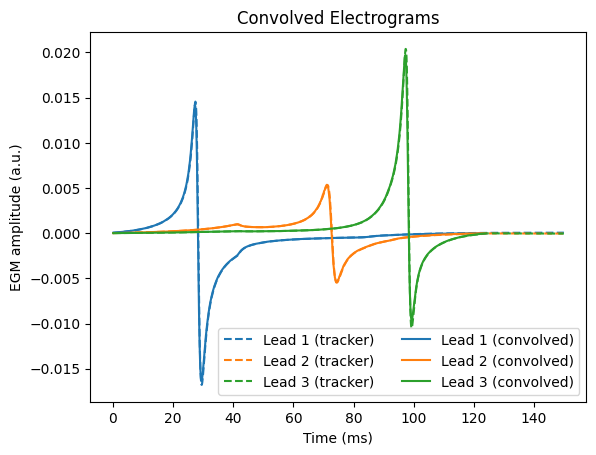

In [7]:
import numpy as np


def convolve_with_template(lat, source_weights, dvdt, act_time, end_time, dt):
    """Calculate EGMs from LAT, spatial source weights, and an AP derivative.

    Parameters
    ----------
    lat : ndarray
        LAT values (ms), flattened internally to P points.
    source_weights : array_like, shape (M, P)
        Conductivity-weighted spatial dot products in the same point order
        as lat. Spatial integration scaling is already in lead_fields.
    dvdt : array_like
        Time derivative of the action potential, sampled at uniform time intervals.
    act_time : float
        Activation time on the AP template clock (ms).
    end_time : float
        Retained derivative sample count times dt (ms), used for time alignment.
    dt : float
        Time step between samples in dvdt (ms).
    
    Returns
    -------
    time_ms : ndarray
        Time points corresponding to the EGM samples (ms).
    egm : ndarray
        Calculated electrograms, shaped (num_electrodes, num_time_points).

    """
    lat_min = lat.min()
    lat_max = lat.max()
    position = ((lat - lat_min) / dt).ravel()
    left = np.floor(position).astype(int)
    fraction = position - left
    n_bins = int(left.max()) + 2

    signals = []
    for electrode_weights in source_weights:
        w = electrode_weights.ravel()

        histogram = np.bincount(left, weights=w * (1 - fraction), minlength=n_bins)
        histogram += np.bincount(left + 1, weights=w * fraction, minlength=n_bins)

        signals.append(np.convolve(histogram, dvdt, mode="full"))

    egm = np.stack(signals)
    right_overlap_time = end_time - act_time
    times = lat_min - right_overlap_time + np.arange(egm.shape[1]) * dt
    mask = (times >= lat_min) & (times <= lat_max)
    time_ms = times[mask]
    egm = egm[:, mask]
    return time_ms, egm

dt = act_pot_tracker.step * simulation.dt
convolved_times, convolved_egms = convolve_with_template(
    lats, source_weights, dvdt, ap_act_time, ap_end_time, dt=dt
    )

tracker_times = ecg_tracker.tracking_times
tracker_egms = ecg_tracker.output

colors = ["C0", "C1", "C2"]
plt.figure()
for i, egm in enumerate(tracker_egms.T):
    plt.plot(tracker_times, egm, label=f"Lead {i + 1} (tracker)", linestyle="--", color=colors[i])

for i, egm in enumerate(convolved_egms):
    plt.plot(convolved_times, egm, label=f"Lead {i + 1} (convolved)", color=colors[i])

plt.title("Convolved Electrograms")
plt.xlabel("Time (ms)")
plt.ylabel("EGM amplitude (a.u.)")
plt.legend(ncol=2)
plt.show()

## 4. Method 2: reconstructed voltages and a discrete operator

This method reconstructs the transmembrane potential throughout the tissue from the LAT map and a common AP template. The electrograms are then obtained by combining these voltages with electrode weights derived from the tissue's diffusion operator.

### 4.1. Reconstruct the nodal voltages

At each tissue node $p$, the AP template is shifted to the local activation time:

$$
V_p(t)=V_0(t-\tau_p+a).
$$

Here $V_0$ is the reference AP waveform, $\tau_p$ is the local activation time, and $a$ is the activation time within the reference waveform. This reconstructs the voltage distribution at any time under the assumption that all nodes share the same AP shape.

### 4.2. Precompute electrode weights and calculate electrograms

Let $L$ contain the electrode lead fields and let $K_{\mathrm{intra}}$ represent the discrete intracellular diffusion operator, including the cell-volume factor for spatial integration. The electrode weights are

$$
B=-L K_{\mathrm{intra}}.
$$

These weights combine the electrode sensitivity with the tissue's conductive properties. They depend on the tissue and electrode configuration and can therefore be precomputed independently of the voltage time course.

The electrogram for electrode $e$ is then

$$
\mathrm{EGM}_e(t)=\sum_p B_{e,p}\,V_p(t).
$$

Each reconstructed nodal voltage is multiplied by its electrode weight, and the contributions are summed over the tissue. This uses the full AP waveform and the tissue's discrete diffusion operator directly, without requiring spatial LAT gradients.

The resulting traces are compared with electrograms from the simulated voltage distribution. Differences can arise because the LAT reconstruction assumes a common AP shape throughout the tissue. Consistent activation-time definitions are also needed to align the reconstructed and simulated signals.


(1500, 3) (1500, 3)


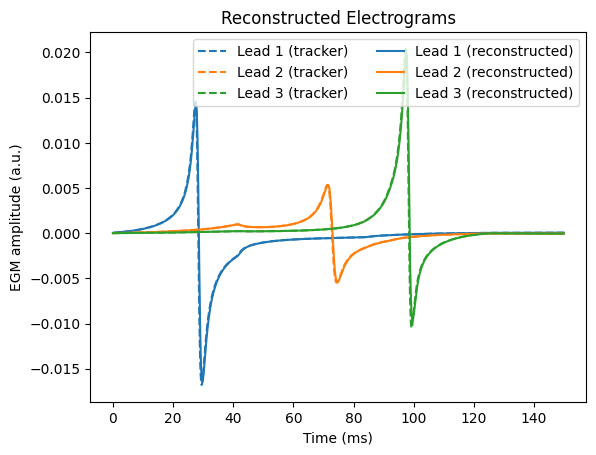

In [ ]:
t_ap = act_pot_tracker.tracking_times
act_pot = np.asarray(act_pot_tracker.output)
lat_shifted = lats.ravel() - ap_act_time

act_pot_nodes = np.interp(
    t_ap[:, None] - lat_shifted[None, :],
    t_ap,
    act_pot,
    left=act_pot[0],
    right=act_pot[-1],
)

diffusion_operator = (- simulation.spatial_discretization.weights[0] * 
                      D_intra / D_model * (dr ** 3))
source_weights = (diffusion_operator.T @ lead_fields.T).T

reconstructed_egms = np.einsum("en,tn->te", source_weights, act_pot_nodes, optimize=True)

colors = ["C0", "C1", "C2"]
plt.figure()
for i, egm in enumerate(tracker_egms.T):
    plt.plot(tracker_times, egm, label=f"Lead {i + 1} (tracker)", linestyle="--", color=colors[i])

for i, egm in enumerate(reconstructed_egms.T):
    plt.plot(tracker_times, egm, label=f"Lead {i + 1} (reconstructed)", color=colors[i])

plt.title("Reconstructed Electrograms")
plt.xlabel("Time (ms)")
plt.ylabel("EGM amplitude (a.u.)")
plt.legend(ncol=2)
plt.show()


## References

1. Pezzuto S., Kal'avský P., Potse M., Prinzen F. W., Auricchio A., and Krause R. (2017). [Evaluation of a Rapid Anisotropic Model for ECG Simulation](https://doi.org/10.3389/fphys.2017.00265). *Frontiers in Physiology*, **8**, 265. Background on activation times, shifted AP templates, and lead-field ECG calculation.
2. Potse M. (2018). [Scalable and Accurate ECG Simulation for Reaction-Diffusion Models of the Human Heart](https://doi.org/10.3389/fphys.2018.00370). *Frontiers in Physiology*, **9**, 370. Lead-field formulation and precomputation of electrode-dependent quantities.